In [1]:
import pandas as pd
import numpy as np
import scanpy
import phate
import scprep
import matplotlib.pyplot as plt
import magic
import leidenalg
import seaborn as sns
from sklearn.preprocessing import scale
import pandas as pd
acute = scanpy.read_h5ad('data/acute_tcells.h5ad')
chronic = scanpy.read_h5ad('data/chronic_tcells.h5ad')

In [4]:
acute = scanpy.read_h5ad('data/acute_tcells.h5ad')
chronic = scanpy.read_h5ad('data/chronic_tcells.h5ad')

In [5]:
adata = scanpy.concat((acute,chronic))
adata.obs['batch'] = adata.obs['batch'].astype('category')

In [49]:
phate_op = phate.PHATE(random_state=42, n_jobs=-1, knn=30)
adata.obsm['X_phate'] = phate_op.fit_transform(adata.to_df())

Calculating PHATE...
  Running PHATE on 44190 observations and 14152 variables.
  Calculating graph and diffusion operator...
    Calculating PCA...
    Calculated PCA in 20.76 seconds.
    Calculating KNN search...
    Calculated KNN search in 60.94 seconds.
    Calculating affinities...
    Calculated affinities in 6.48 seconds.
  Calculated graph and diffusion operator in 88.73 seconds.
  Calculating landmark operator...
    Calculating SVD...
    Calculated SVD in 19.59 seconds.
    Calculating KMeans...
    Calculated KMeans in 5.31 seconds.
  Calculated landmark operator in 27.07 seconds.
  Calculating optimal t...
    Automatically selected t = 24
  Calculated optimal t in 2.11 seconds.
  Calculating diffusion potential...
  Calculated diffusion potential in 0.64 seconds.
  Calculating metric MDS...
  Calculated metric MDS in 4.61 seconds.
Calculated PHATE in 123.18 seconds.


In [ ]:
magic_op = magic.MAGIC()
data_magic = magic_op.fit_transform(adata.to_df(), genes=hvgs, graph=phate_op.graph)

In [2]:
gene_embedding_results = np.load('results/GSPA_QR_without_regression.npz', allow_pickle=True)

In [3]:
data_ae = gene_embedding_results['signal_embedding']
localization = gene_embedding_results['localization_score']
hvgs = gene_embedding_results['genes']

In [4]:
gene_phate_op = phate.PHATE(random_state=42)
data_phate = gene_phate_op.fit_transform(data_ae)

Calculating PHATE...
  Running PHATE on 1416 observations and 128 variables.
  Calculating graph and diffusion operator...
    Calculating PCA...
    Calculated PCA in 0.03 seconds.
    Calculating KNN search...
    Calculated KNN search in 0.18 seconds.
    Calculating affinities...
    Calculated affinities in 0.01 seconds.
  Calculated graph and diffusion operator in 0.23 seconds.
  Calculating optimal t...
    Automatically selected t = 29
  Calculated optimal t in 0.61 seconds.
  Calculating diffusion potential...
  Calculated diffusion potential in 0.30 seconds.
  Calculating metric MDS...
  Calculated metric MDS in 1.73 seconds.
Calculated PHATE in 2.88 seconds.


<AxesSubplot:title={'center':'Gene clusters'}, xlabel='Gene PHATE1', ylabel='Gene PHATE2'>

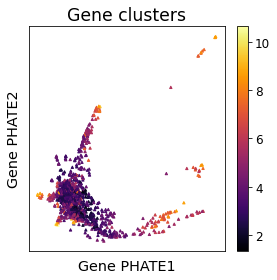

In [9]:
scprep.plot.scatter2d(data_phate, ticks=None, figsize=(4,4), c=localization, dpi=200, filename='figures/localization.png',
                          title='Gene clusters', label_prefix='Gene PHATE', legend_loc=(1.05,0), marker='^')

## localization

In [217]:
localization = pd.Series(localization, index=hvgs)

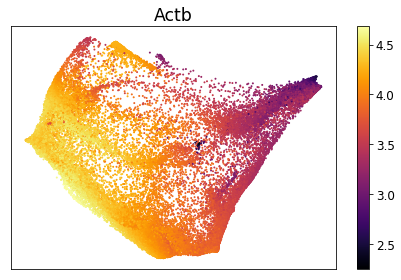

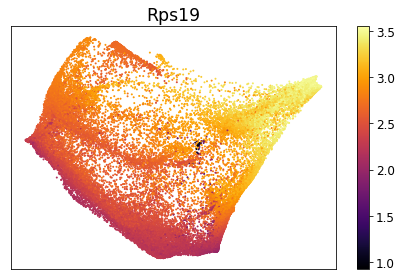

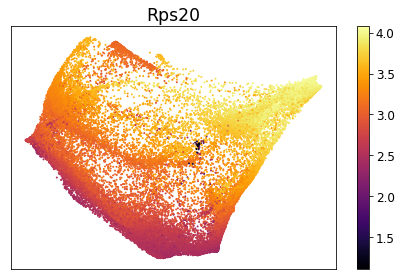

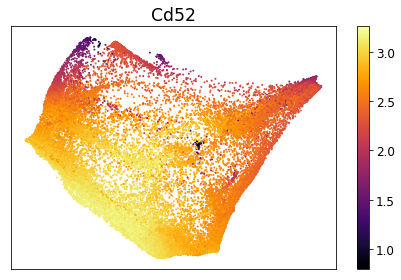

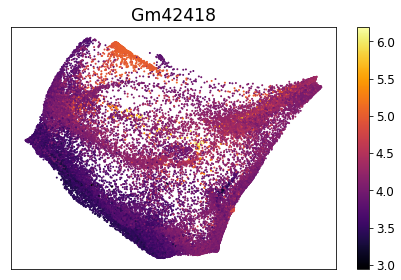

In [227]:
for gene in localization.sort_values(ascending=True)[:5].index:
    scprep.plot.scatter2d(adata.obsm['X_phate'], c=data_magic[gene], title=gene, ticks=None)

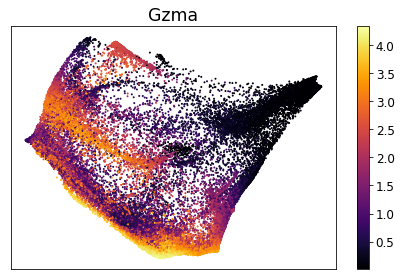

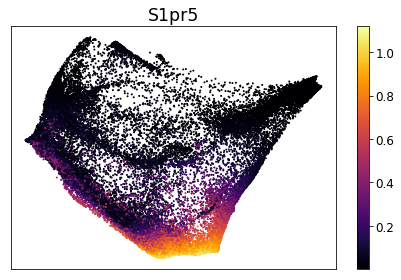

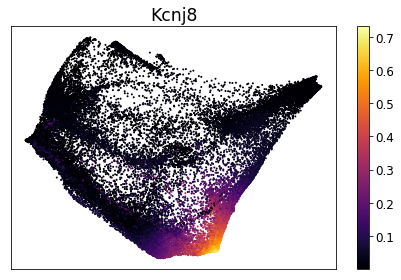

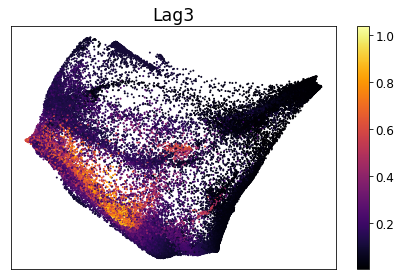

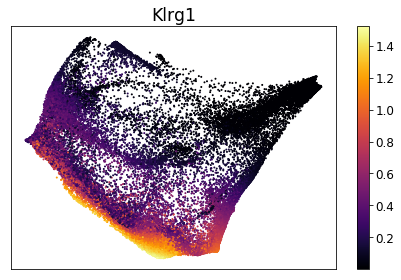

In [228]:
for gene in localization.sort_values(ascending=False)[:5].index:
    scprep.plot.scatter2d(adata.obsm['X_phate'], c=data_magic[gene], title=gene, ticks=None)

In [236]:
cell_clusters = np.array(leidenalg.find_partition(phate_op.graph.to_igraph(), 
                                                  leidenalg.ModularityVertexPartition,
                                                  seed=0).membership)

<AxesSubplot:>

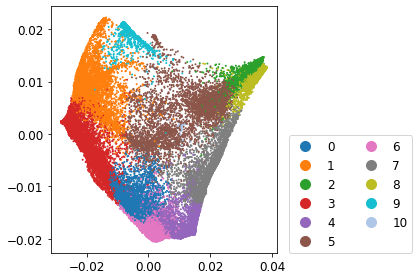

In [238]:
scprep.plot.scatter2d(adata.obsm['X_phate'], c=cell_clusters, legend_loc=(1.05,0))

In [242]:
adata.obs['clusters'] = cell_clusters.astype(str)

In [243]:
scanpy.tl.rank_genes_groups(adata, groupby='clusters', method='wilcoxon')

In [305]:
genes_max_score_clustering = []
for gene in hvgs:
    max_score = -1
    for cluster in [str(x) for x in range(11)]:
        score = dict(zip(adata.uns['rank_genes_groups']['names'][cluster], 
                         adata.uns['rank_genes_groups']['scores'][cluster]))[gene]
        if score > max_score:
            max_score = score
    genes_max_score_clustering.append(max_score)

In [311]:
gene_summary['clustering_rank'] = genes_max_score_clustering

In [313]:
gene_summary.to_csv('results/gene_summary.csv')

In [319]:
gene_summary[gene_summary.columns[1:]].corr(method='spearman')

,localization_score,clustering_rank
localization_score,1.00000,0.29424
clustering_rank,0.29424,1.00000


/usr/lib/python3.8/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


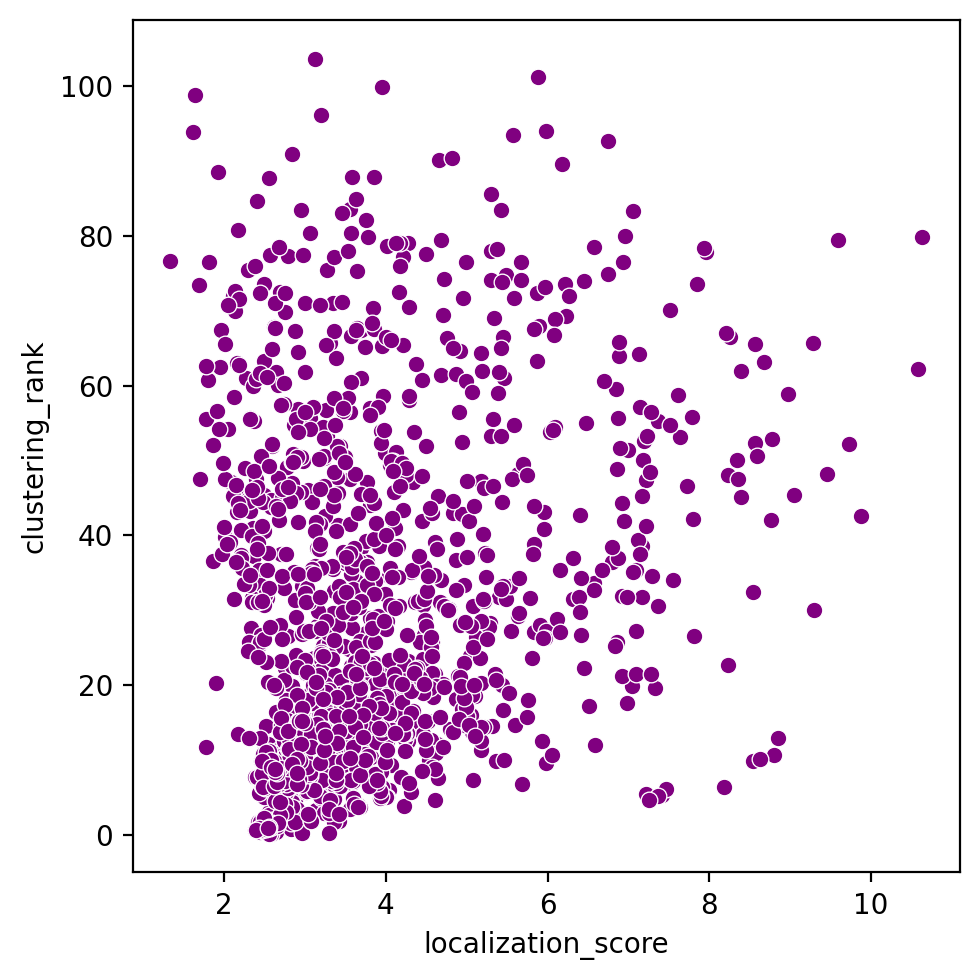

In [359]:
fig, ax = plt.subplots(figsize=(5,5), dpi=200)
sns.scatterplot(gene_summary['localization_score'], gene_summary['clustering_rank'], ax=ax, color='purple')
plt.tight_layout()
fig.savefig('figures/localization_vs_clustering.png', dpi=200)

In [327]:
gene_summary.sort_values('clustering_rank', ascending=False)[:]

,gene_clusters,localization_score,clustering_rank
Ptma,2,3.127668,103.669586
Pclaf,8,5.887194,101.171829
Hmgb2,2,3.950957,99.832710
Rps20,3,1.635922,98.867584
Ran,2,3.192183,96.122696
S100a4,1,5.974631,94.082520
Rps19,3,1.617332,93.823494
Stmn1,2,5.574742,93.434563
Birc5,2,6.751680,92.708969
H2afz,2,2.839092,90.919891


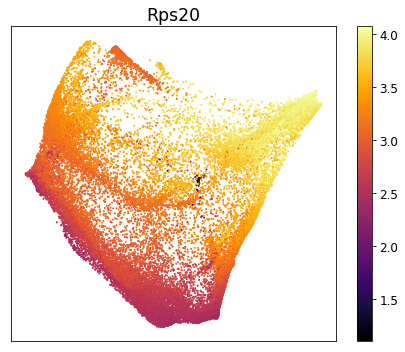

In [353]:
for gene in ['Rps20']:
    scprep.plot.scatter2d(adata.obsm['X_phate'], c=data_magic[gene], title=gene, ticks=None, figsize=(6,5),
                          dpi=200, filename=f'figures/{gene}.png')

In [333]:
gene_summary.sort_values('localization_score', ascending=False)[:]

,gene_clusters,localization_score,clustering_rank
Gzma,1,10.634704,79.793770
S1pr5,1,10.585837,62.191685
Kcnj8,9,9.875958,42.622658
Lag3,7,9.728943,52.187080
Klrg1,1,9.586405,79.399185
...,...,...,...
Gm42418,6,1.702121,47.506950
Cd52,1,1.692307,73.472733
Rps20,3,1.635922,98.867584
Rps19,3,1.617332,93.823494


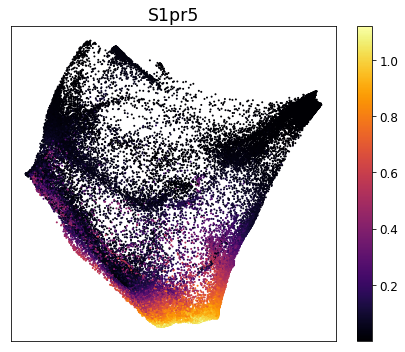

In [354]:
for gene in ['S1pr5']:
    scprep.plot.scatter2d(adata.obsm['X_phate'], c=data_magic[gene], title=gene, ticks=None, figsize=(6,5),
                          dpi=200, filename=f'figures/{gene}.png')

In [355]:
gene_summary[(gene_summary['localization_score'] > 8) & (gene_summary['clustering_rank'] < 20)]

,gene_clusters,localization_score,clustering_rank
Cd79a,10,8.178978,6.341754
H2-Ab1,10,8.543336,9.904192
H2-Aa,10,8.805617,10.656022
H2-Eb1,10,8.631687,10.118419
Cd74,10,8.847000,12.898121


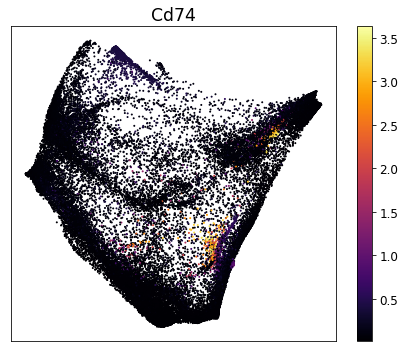

In [356]:
for gene in ['Cd74']:
    scprep.plot.scatter2d(adata.obsm['X_phate'], c=data_magic[gene], title=gene, ticks=None, figsize=(6,5),
                          dpi=200, filename=f'figures/{gene}.png')